# Lab - 2

### Name: Anumalasetty Sohan Kumar  
### Roll No: CS23B1004
### Name: Shishir Kumar Reddy Ambala 
### Roll No: CS23B2043

---
## Question 1

Q1. Classify MNIST digits using Fully Connected Neural network.  
Dataset : Download from internet source

- Plot few samples from dataset
- Train the network 
- Test on the test dataset
- Calculate test accuracy on test set


---

In [43]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split

## Activation functions

In [54]:
def sigmoid(z):
    return 1 / (1 + np.exp(-np.clip(z, -500, 500)))

def delta_sigmoid(z):
    s = sigmoid(z)
    return s * (1 - s)

def relu(z):
    return np.maximum(0, z)

def delta_relu(z):
    return (z > 0).astype(float)

def softmax(z):
    exp_z = np.exp(z - np.max(z, axis=1, keepdims=True))
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)

## Fully Connected Neural Network

In [ ]:
class Layer:
    def __init__(self, input_size, output_size, activation='sigmoid'):
        self.W = np.random.randn(input_size, output_size) * np.sqrt(2.0 / input_size)
        self.b = np.zeros((1, output_size))
        self.activation = activation
        
    def forward(self, X):
        self.X = X
        self.Z = X @ self.W + self.b
        
        if self.activation == 'sigmoid':
            self.A = sigmoid(self.Z)
        elif self.activation == 'relu':
            self.A = relu(self.Z)
        elif self.activation == 'softmax':
            self.A = softmax(self.Z)
        else:
            self.A = self.Z
            
        return self.A
    
    def backward(self, dA, alpha):
        m = self.X.shape[0]
        
        if self.activation == 'sigmoid':
            dZ = dA * delta_sigmoid(self.Z)
        elif self.activation == 'relu':
            dZ = dA * delta_relu(self.Z)
        elif self.activation == 'softmax':
            dZ = dA
        else:
            dZ = dA
            
        dW = (1/m) * (self.X.T @ dZ)
        db = (1/m) * np.sum(dZ, axis=0, keepdims=True)
        dX = dZ @ self.W.T
        
        self.W -= alpha * dW
        self.b -= alpha * db
        
        return dX

## Using Mini-Batch GD for faster Convergence

In [56]:
class NeuralNetwork:
    def __init__(self, layer_sizes, activations):
        self.layers = []
        for i in range(len(layer_sizes) - 1):
            layer = Layer(layer_sizes[i], layer_sizes[i+1], activations[i])
            self.layers.append(layer)
    
    def forward(self, X):
        A = X
        for layer in self.layers:
            A = layer.forward(A)
        return A
    
    def backward(self, dA, alpha):
        for layer in reversed(self.layers):
            dA = layer.backward(dA, alpha)
    
    def train(self, X_train, y_train, epochs, alpha, batch_size=128):
        m = X_train.shape[0]
        losses = []
        
        for epoch in range(epochs):
            permutation = np.random.permutation(m)
            X_shuffled = X_train[permutation]
            y_shuffled = y_train[permutation]
            
            epoch_loss = 0
            num_batches = m // batch_size
            
            for i in range(0, m, batch_size):
                X_batch = X_shuffled[i:i+batch_size]
                y_batch = y_shuffled[i:i+batch_size]
                
                predictions = self.forward(X_batch)
                
                # Compute loss (cross-entropy)
                batch_loss = -np.mean(np.sum(y_batch * np.log(predictions + 1e-8), axis=1))
                epoch_loss += batch_loss
                
                dA = predictions - y_batch
                self.backward(dA, alpha)
            
            avg_loss = epoch_loss / num_batches
            losses.append(avg_loss)
            
            if (epoch + 1) % 10 == 0:
                accuracy = self.evaluate(X_train, y_train)
                print(f'Epoch {epoch+1}/{epochs}, Loss: {avg_loss:.4f}, Train Accuracy: {accuracy:.4f}')
        
        return losses
    
    def predict(self, X):
        predictions = self.forward(X)
        return np.argmax(predictions, axis=1)
    
    def evaluate(self, X, y):
        predictions = self.predict(X)
        true_labels = np.argmax(y, axis=1)
        accuracy = np.mean(predictions == true_labels)
        return accuracy

## Load Dataset

In [57]:
df = pd.read_csv(r'mnist_train.csv')
df.shape

(60000, 785)

## Normalizing the Pixel values

In [58]:
X = df.iloc[:, 1:].values.astype(np.float32)
y = df.iloc[:, 0].values.astype(int)

X /= 255.0

## Split dataset

In [59]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

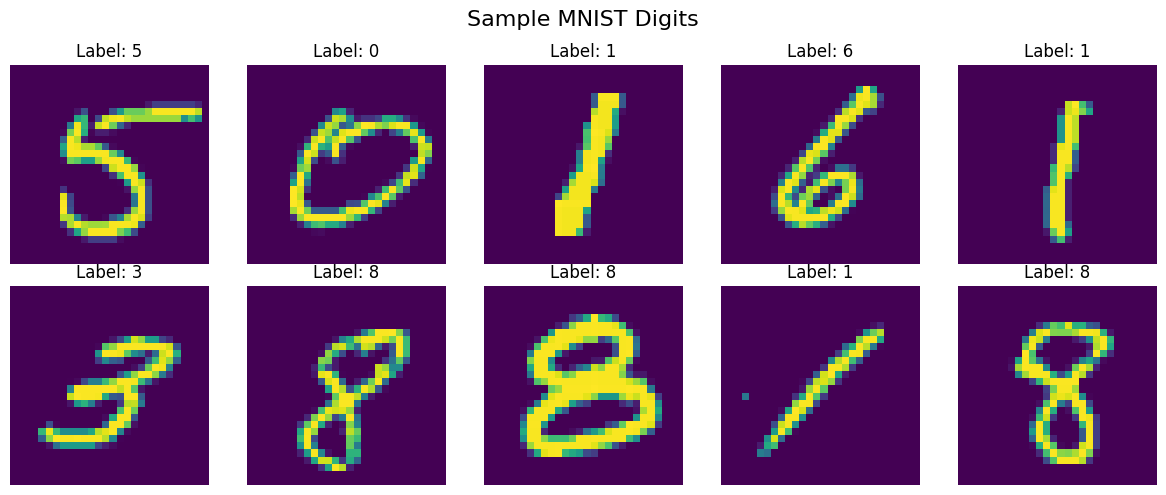

In [60]:
# Plot few samples from dataset
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
fig.suptitle('Sample MNIST Digits', fontsize=16)
for i, ax in enumerate(axes.flat):
    ax.imshow(X_train[i].reshape(28, 28), cmap='viridis')
    ax.set_title(f'Label: {y_train[i]}')
    ax.axis('off')
plt.tight_layout()
plt.show()

## For categorical cross entropy --> we use OHE

In [61]:
ohe = OneHotEncoder(sparse_output=False)
y_train_encoded = ohe.fit_transform(y_train.reshape(-1, 1))
y_test_encoded = ohe.transform(y_test.reshape(-1, 1))

print(y_train_encoded.shape)
print(y_test_encoded.shape)

(48000, 10)
(12000, 10)


In [62]:
print(f"X_train: {X_train.shape}")
print(f"X_test: {X_test.shape}")
print(f"y_train: {y_train_encoded.shape}")
print(f"y_test: {y_test_encoded.shape}")

X_train: (48000, 784)
X_test: (12000, 784)
y_train: (48000, 10)
y_test: (12000, 10)


### - **Architecture**: 784 (input) -> 128 -> 64 -> 10(output)
### - **Loss Fn** : Categorical Cross Entropy
### - **Activation functions in hidden layer** : sigmoid
### - **Activation function in output layer** : softmax (as multiclass classification) 

In [63]:
layer_sizes = [784, 128, 64, 10]
activations = ['sigmoid', 'sigmoid', 'softmax']

print("\nCreating Neural Network...")
print(f"Architecture: {' -> '.join(map(str, layer_sizes))}")
print(f"Activations: {activations}")

nn = NeuralNetwork(layer_sizes, activations)    

# Train the network
print("\nTraining Neural Network...")
epochs = 100
learning_rate = 0.1
batch_size = 128

losses = nn.train(X_train, y_train_encoded, epochs, learning_rate, batch_size)


Creating Neural Network...
Architecture: 784 -> 128 -> 64 -> 10
Activations: ['sigmoid', 'sigmoid', 'softmax']

Training Neural Network...
Epoch 10/100, Loss: 0.2814, Train Accuracy: 0.9205
Epoch 20/100, Loss: 0.2055, Train Accuracy: 0.9408
Epoch 30/100, Loss: 0.1586, Train Accuracy: 0.9556
Epoch 40/100, Loss: 0.1265, Train Accuracy: 0.9654
Epoch 50/100, Loss: 0.1030, Train Accuracy: 0.9727
Epoch 60/100, Loss: 0.0855, Train Accuracy: 0.9775
Epoch 70/100, Loss: 0.0718, Train Accuracy: 0.9811
Epoch 80/100, Loss: 0.0609, Train Accuracy: 0.9839
Epoch 90/100, Loss: 0.0518, Train Accuracy: 0.9874
Epoch 100/100, Loss: 0.0443, Train Accuracy: 0.9898


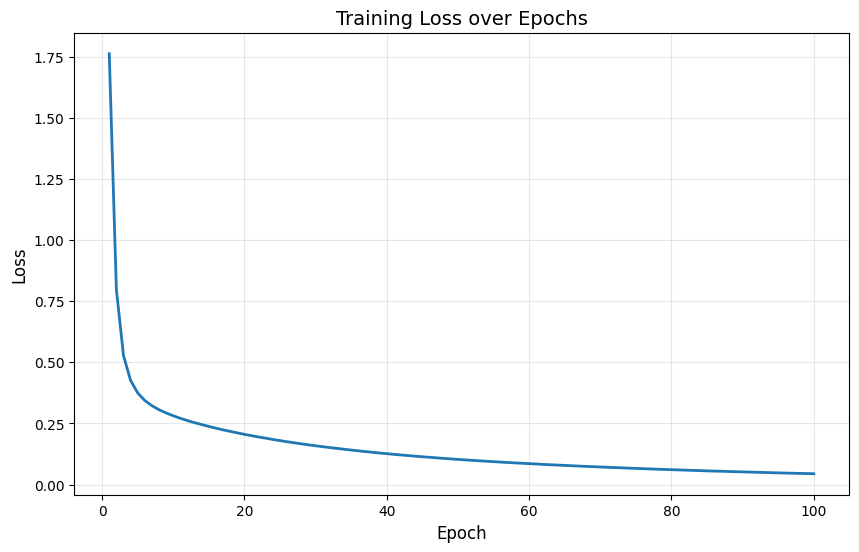

In [64]:
plt.figure(figsize=(10, 6))
plt.plot(range(1, epochs+1), losses, linewidth=2)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.title('Training Loss over Epochs', fontsize=14)
plt.grid(True, alpha=0.3)
plt.show()

## Model Evaluation on Test data

In [65]:
test_accuracy = nn.evaluate(X_test, y_test_encoded)
train_accuracy = nn.evaluate(X_train, y_train_encoded)

In [67]:
print(f"Train Accuracy: {train_accuracy*100:.2f}%")
print(f"Test Accuracy:  {test_accuracy*100:.2f}%")

Train Accuracy: 98.98%
Test Accuracy:  97.34%


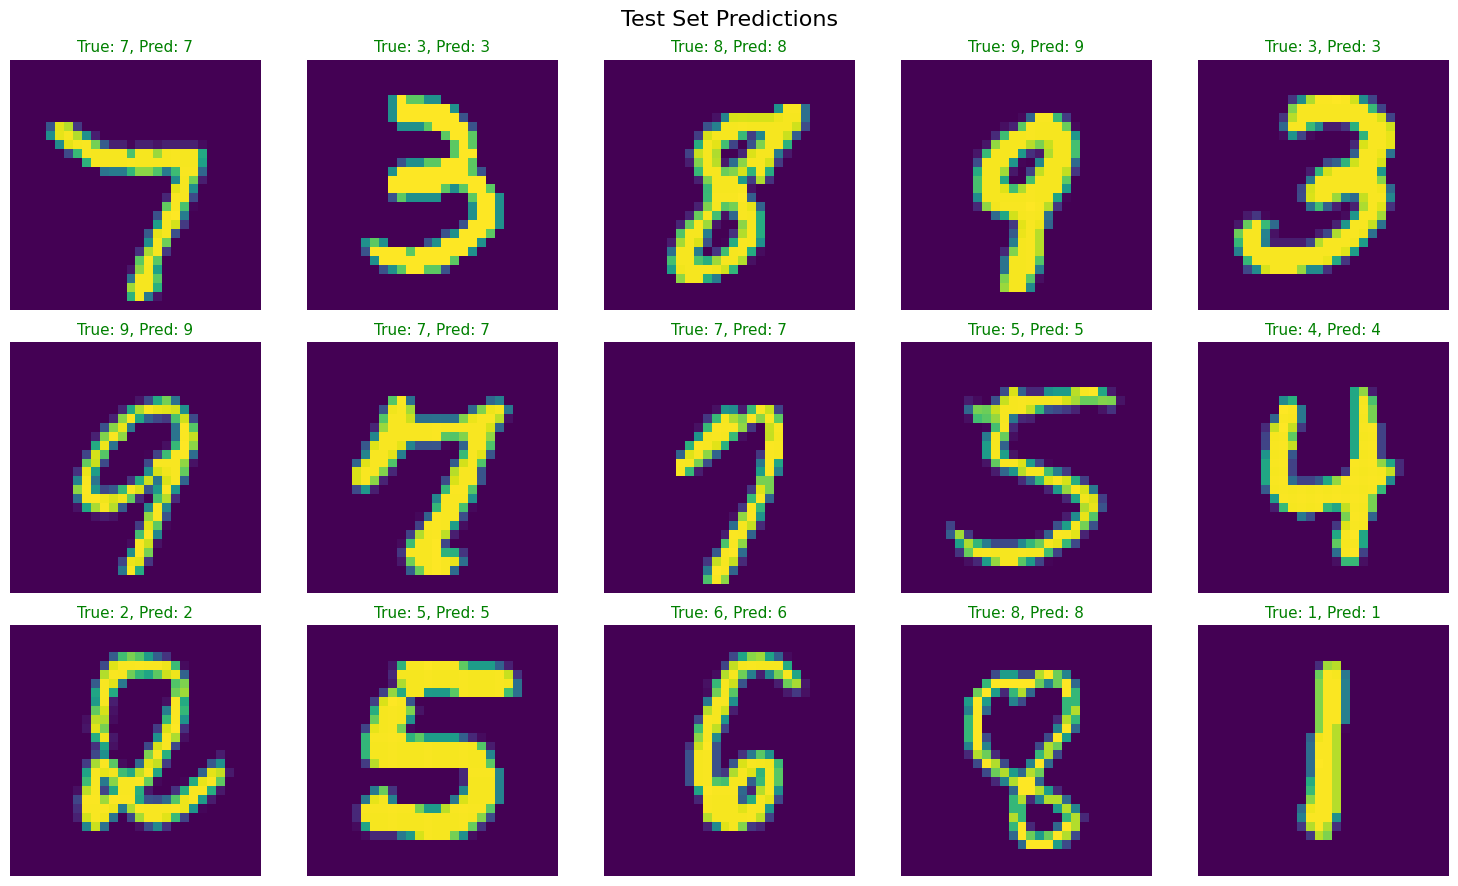

In [68]:
predictions = nn.predict(X_test)
fig, axes = plt.subplots(3, 5, figsize=(15, 9))
fig.suptitle('Test Set Predictions', fontsize=16)

for i, ax in enumerate(axes.flat):
    ax.imshow(X_test[i].reshape(28, 28), cmap='viridis')
    true_label = y_test[i]
    pred_label = predictions[i]
    color = 'green' if true_label == pred_label else 'red'
    ax.set_title(f'True: {true_label}, Pred: {pred_label}', color=color, fontsize=11)
    ax.axis('off')
plt.tight_layout()
plt.show()